<a href="https://colab.research.google.com/github/dai-fujiden/boite-a-jouets/blob/main/snow_simu/snowflake_heat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation  # [FIX] save_gif で使うのに import 漏れしていた
from scipy.spatial import cKDTree
from tqdm import tqdm
import pandas as pd

@dataclass
class ParticleState:
    time: float
    position: np.ndarray      # (dim, n_particle)
    frag: np.ndarray          # (n_particle,)  True = 吸着済み(固定), False = 拡散中(active)


class Particle:
    def __init__(
        self,
        nums=100,
        tmax=100,
        dt=1.0,
        # [CHANGE] box用のパラメータ(従来通り)
        particle_init_posi_range=[[20, 40], [20, 40], [20, 40]],
        # [NEW] 円形配置用のパラメータ
        init_shape="box",       # "box" または "circle"
        init_center=None,       # 円の中心 (x, y) ※init_shape="circle"のとき使用
        init_radius=10.0,       # 円の半径 ※init_shape="circle"のとき使用
        init_radius_inner=0.0,  # [NEW] ドーナツ状にしたい場合の内径(通常は0でOK)
        boundary=[[0, 100], [0, 100], [0, 100]],
        T_ambient=-15.0,
        T_freeze=0.0,
        latent_heat=8.0,
        diffusivity=0.20,
        cooling_rate=0.02,
        stick_temp_scale=2.0,
        record_temp_history=False,
        temp_record_every=5,
    ):
        self.n_particle = nums
        self.dim = len(boundary)

        self.time = 0.0
        self.tmax = tmax
        self.dt = dt
        self.t = np.arange(0, tmax + dt, dt)

        self.boundary = [[int(b[0]), int(b[1])] for b in boundary]

        # ------------------------
        # 温度場の初期化
        # ------------------------
        self.T_ambient = T_ambient
        self.T_freeze = T_freeze
        self.latent_heat = latent_heat
        self.diffusivity = diffusivity
        self.cooling_rate = cooling_rate
        self.stick_temp_scale = stick_temp_scale
        self.record_temp_history = record_temp_history
        self.temp_record_every = temp_record_every
        self.temp_snapshots = []

        if self.dim == 2:
            gx = self.boundary[0][1] - self.boundary[0][0] + 1
            gy = self.boundary[1][1] - self.boundary[1][0] + 1
            self.temp_field = np.full((gx, gy), T_ambient, dtype=float)
        else:
            self.temp_field = None

        # ------------------------
        # [NEW] 初期位置(box or circle)
        # ------------------------
        if init_shape == "circle":
            if self.dim != 2:
                raise ValueError("circle配置は現状2次元のみ対応です")

            if init_center is None:
                # [NEW] 指定がなければboundaryの中心をデフォルトにする
                cx = (self.boundary[0][0] + self.boundary[0][1]) / 2
                cy = (self.boundary[1][0] + self.boundary[1][1]) / 2
            else:
                cx, cy = init_center

            # [NEW] 面積一様分布になるよう半径をsqrtでサンプリング
            u = np.random.uniform(0, 1, nums)
            r = np.sqrt(
                init_radius_inner**2 + u * (init_radius**2 - init_radius_inner**2)
            )
            theta = np.random.uniform(0, 2 * np.pi, nums)

            x = np.round(cx + r * np.cos(theta)).astype(int)
            y = np.round(cy + r * np.sin(theta)).astype(int)

            # [NEW] boundary内にクリップ(念のため)
            x = np.clip(x, self.boundary[0][0], self.boundary[0][1])
            y = np.clip(y, self.boundary[1][0], self.boundary[1][1])

            self.init_position = np.array([x, y])

        elif init_shape == "box":
            init_position = []
            for rng in particle_init_posi_range:
                init_position.append(np.random.randint(rng[0], rng[1], nums))
            self.init_position = np.array(init_position)

        else:
            raise ValueError(f"未対応のinit_shape: {init_shape}")

        self.init_frag = np.zeros(nums, dtype=bool)

        # ------------------------
        # 時系列データ
        # ------------------------
        self.states = []
        for i, t in enumerate(tqdm(self.t, desc="Allocating states")):
            if i == 0:
                position = self.init_position.copy()
            else:
                position = np.zeros_like(self.init_position)
            self.states.append(
                ParticleState(time=t, position=position, frag=self.init_frag.copy())
            )
    def __repr__(self):
        return (
            f"Particle("
            f"n_particle={self.n_particle}, "
            f"dimension={self.dim}, "
            f"n_step={len(self.states)})"
        )
    def _diffuse_temperature(self):
        """温度場を1ステップ拡散させ、環境温度へ緩和する"""
        if self.temp_field is None:
            return
        T = self.temp_field
        # 5点ラプラシアン(周期境界を簡易的に使用)
        lap = (
            np.roll(T, 1, axis=0) + np.roll(T, -1, axis=0) +
            np.roll(T, 1, axis=1) + np.roll(T, -1, axis=1) - 4.0 * T
        )
        self.temp_field = T + self.diffusivity * lap - self.cooling_rate * (T - self.T_ambient)
    def _to_grid_idx(self, pos):
        """position配列(dim, n) を温度場のインデックスに変換する"""
        ix = np.clip(
            np.round(pos[0]).astype(int) - self.boundary[0][0],
            0, self.temp_field.shape[0] - 1
        )
        iy = np.clip(
            np.round(pos[1]).astype(int) - self.boundary[1][0],
            0, self.temp_field.shape[1] - 1
        )
        return ix, iy
    def add_active_particles(self, added_position=None, added_time=0):
        """
        既存の粒子集団に、新たな粒子(典型的には最初から吸着済みの「核」)を追加する。

        [FIX] グローバル変数 particle.states を参照していたバグを self.states に修正。
        [NOTE] added_time は現状 self.states[0].time (=シミュレーション開始時刻) を
               想定しています。途中の時刻から粒子を追加する場合、それより前の
               ステップの position 配列サイズと self.n_particle が食い違い
               shape mismatch になるため、その場合は事前に警告します。
        """
        print(f"Old property "
              f"n_particle={self.n_particle}, "
              f"dimension={self.dim}, "
              f"n_step={len(self.states)}")
        print("-----------" * 6)

        added_position = np.array(added_position, dtype=float)
        added_nums = added_position.shape[1]

        if added_time > self.states[0].time:
            print(
                f"[WARNING] added_time={added_time} は開始時刻"
                f"{self.states[0].time} より後です。"
                f"added_time より前のステップは position の配列サイズが"
                f"self.n_particle と食い違うため、update() 実行時にエラーになる"
                f"可能性があります。added_time=0 での利用を推奨します。"
            )

        for state in self.states:  # [FIX] self.states を参照
            if state.time >= added_time:
                state.position = np.concatenate((state.position, added_position), axis=1)
                state.frag = np.concatenate((state.frag, np.ones(added_nums, dtype=bool)))

        self.n_particle = self.n_particle + added_nums
        print(f"Updated property "
              f"n_particle={self.n_particle}, "
              f"dimension={self.dim}, "
              f"n_step={len(self.states)}")

    def update_loop(self, step: int, dx_range: list = [-1, 1], dy_range: list = [-1, 1], fix_inactive=True):
        if step == 0:
            return

        state = self.states[step]
        _state = self.states[step - 1]

        # [FIX] 前ステップの吸着状態(frag)をこのステップに引き継ぐ。
        # これをしないと、各stepのfragが__init__/add_active_particles時点の
        # 初期状態のまま上書きされず、途中で吸着した粒子が
        # 次のstepでは「未吸着」に戻ってしまい、初期の核以外に吸着が広がらなかった。
        state.frag = _state.frag.copy()

        # 1. 移動量の生成
        dx = np.random.randint(dx_range[0], dx_range[1] + 1, self.n_particle)
        dy = np.random.randint(dy_range[0], dy_range[1] + 1, self.n_particle)

        # 2. 吸着済み(frag=True)粒子の移動を固定
        if fix_inactive:
            dx[_state.frag] = 0
            dy[_state.frag] = 0

        # 3. 位置の仮更新
        state.position[0] = _state.position[0] + dx
        if self.dim >= 2:
            state.position[1] = _state.position[1] + dy

        # (以下、境界処理は変更なし)
        xmin, xmax = self.boundary[0][0], self.boundary[0][1]

        under_x = state.position[0] < xmin
        if np.any(under_x):
            state.position[0][under_x] = 2 * xmin - state.position[0][under_x]

        over_x = state.position[0] > xmax
        if np.any(over_x):
            state.position[0][over_x] = 2 * xmax - state.position[0][over_x]

        if self.dim >= 2:
            ymin, ymax = self.boundary[1][0], self.boundary[1][1]

            under_y = state.position[1] < ymin
            if np.any(under_y):
                state.position[1][under_y] = 2 * ymin - state.position[1][under_y]

            over_y = state.position[1] > ymax
            if np.any(over_y):
                state.position[1][over_y] = 2 * ymax - state.position[1][over_y]

    def update(self, dx_range=[-1, 1], dy_range=[-1, 1], fix_inactive=True):
        """全ステップにわたってランダムウォークを適用する"""
        for i in tqdm(range(len(self.states)), desc="Updating Simulation"):
            self.update_loop(step=i, dx_range=dx_range, dy_range=dy_range, fix_inactive=fix_inactive)
            self._diffuse_temperature()  # [NEW] 温度場を先に拡散させる
            self.absorp_judge(step=i)

            # [NEW] 温度場のスナップショットを記録(アニメーション用)
            if self.record_temp_history and self.temp_field is not None and i % self.temp_record_every == 0:
                self.temp_snapshots.append((i, self.temp_field.copy()))

            if not np.any(~self.states[i].frag):
                print(f"iter {i}: 全粒子が吸着済みのため終了します")
                break

    def absorp_judge(self, step):
        """
        active粒子がinactive粒子と4近傍(上下左右)で接触した場合、
        [NEW] 接触箇所の局所温度に応じたシグモイド確率で着氷させる。
        温度が低い(=T_freezeより十分低い)ほど着氷しやすく、
        潜熱で暖まった場所の近くでは着氷しにくくなる。
        """
        state = self.states[step]
        active = ~state.frag
        inactive = state.frag

        if not np.any(inactive) or not np.any(active):
            return

        active_idx = np.where(active)[0]
        active_pos = state.position[:, active].T
        inactive_pos = state.position[:, inactive].T

        tree = cKDTree(inactive_pos)
        dist, _ = tree.query(active_pos, k=1, p=1)  # マンハッタン距離(4近傍)
        touching = dist <= 1

        if not np.any(touching):
            return

        cand_idx = active_idx[touching]

        if self.temp_field is not None:
            cand_pos = state.position[:, cand_idx]
            ix, iy = self._to_grid_idx(cand_pos)
            T_local = self.temp_field[ix, iy]

            # [NEW] シグモイド型の着氷確率: 低温ほど1に近く、高温ほど0に近い
            p_stick = 1.0 / (1.0 + np.exp((T_local - self.T_freeze) / self.stick_temp_scale))
            rand_vals = np.random.random(len(cand_idx))
            newly_absorbed_idx = cand_idx[rand_vals < p_stick]
        else:
            newly_absorbed_idx = cand_idx  # 温度場なしなら従来通り確定的に吸着

        if len(newly_absorbed_idx) == 0:
            return

        state.frag[newly_absorbed_idx] = True

        # [NEW] 凍結によって放出される潜熱を温度場に加算
        if self.temp_field is not None:
            fx, fy = self._to_grid_idx(state.position[:, newly_absorbed_idx])
            np.add.at(self.temp_field, (fx, fy), self.latent_heat)

    def get_state(self, step):
        return self.states[step]

    def plot(self, step=0, figsize=(3, 3), dpi=150, particle_size=1, save_path=None, show=True, show_temp=False):
        state = self.states[step]

        if self.dim == 2:
            fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

            ax.set_xlim(self.boundary[0])
            ax.set_ylim(self.boundary[1])

            # [NEW] 温度場を背景ヒートマップとして表示
            if show_temp and self.temp_field is not None:
                ax.imshow(
                    self.temp_field.T,
                    origin="lower",
                    extent=[self.boundary[0][0], self.boundary[0][1],
                            self.boundary[1][0], self.boundary[1][1]],
                    cmap="coolwarm",
                    alpha=0.25,
                    zorder=1,
                )

            active = ~state.frag
            inactive = state.frag

            scat_active = ax.scatter(
                state.position[0][active], state.position[1][active],
                s=particle_size, facecolors="#f58a8a", edgecolors="#b41f1f",
                alpha=0.8, lw=0.5, label="Active", zorder=2,
            )
            scat_absorbed = ax.scatter(
                state.position[0][inactive], state.position[1][inactive],
                s=particle_size, facecolors="#14d8f1", edgecolors="#3877ec",
                alpha=0.9, marker="s", lw=0.5, label="Absorbed", zorder=3,
            )

            ax.set_xlabel("x")
            ax.set_ylabel("y")
            title = ax.set_title(f"$t={state.time:.2f}$")
            ax.set_aspect("equal")
            ax.tick_params(direction="in")
            ax.legend(frameon=False)
            ax.grid(False)
            fig.tight_layout()

            if save_path is not None:
                fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
            if show:
                plt.show()

            return fig, ax, scat_active, scat_absorbed, title

    def save_gif(self, filename="simulation.gif", fps=20, figsize=(4, 4), dpi=80,
                particle_size=1, frame_step=5):
        if self.dim != 2:
            raise ValueError("GIF creation is only supported for 2D simulations.")

        frame_indices = list(range(0, len(self.states), frame_step))
        print(f"Total steps: {len(self.states)}, rendering {len(frame_indices)} frames")

        # [FIX] plot()が返す散布図オブジェクトをそのまま使い回す(二重描画をやめる)
        fig, ax, scat_active, scat_absorbed, title = self.plot(
            step=0, figsize=figsize, dpi=dpi, particle_size=particle_size, show=False, show_temp=True)

        ax.legend(frameon=False, loc="upper right")

        def update_frame(idx):
            state = self.states[idx]
            active = ~state.frag
            absorbed = state.frag

            scat_active.set_offsets(np.c_[state.position[0][active], state.position[1][active]])
            scat_absorbed.set_offsets(np.c_[state.position[0][absorbed], state.position[1][absorbed]])
            title.set_text(f"$t={state.time:.2f}$")
            return scat_active, scat_absorbed, title

        ani = animation.FuncAnimation(
            fig, update_frame, frames=frame_indices, interval=1000 / fps, blit=False
        )

        print(f"Saving GIF to {filename}...")
        ani.save(filename, writer="pillow", fps=fps, dpi=dpi)
        plt.close(fig)
        print("GIF save completed!")
    def make_dataframe(self, step=0):
        """指定したステップの状態をpandas.DataFrameに変換する"""
        state = self.states[step]

        # positionは (dim, n_particle) なので転置して (n_particle, dim) にする
        posi = state.position.T

        # 次元数に応じた列名を作成 (例: 2次元なら ["x", "y"], 3次元なら ["x", "y", "z"])
        columns = ["x", "y", "z"][:self.dim]

        # pandas DataFrameを作成
        df = pd.DataFrame(posi, columns=columns)

        # 吸着状態フラグを追加
        df["is_absorbed"] = state.frag

        return df


In [2]:
particle = Particle(
    nums=1000, tmax=12000,
    boundary=[[0, 150], [0, 150]],
    particle_init_posi_range=[[0, 150], [0, 150]],
    T_ambient=-15.0,
    latent_heat=10.0,
    diffusivity=0.2,
    cooling_rate=0.03,
    stick_temp_scale=1.5,
    record_temp_history=True,
)

thetas = np.linspace(0, 2 * np.pi, 20)
x_active = 75 + 1 * np.cos(thetas)
y_active = 75 + 1 * np.sin(thetas)
particle.add_active_particles(added_position=np.array([x_active, y_active]), added_time=0)

particle.update(fix_inactive=True)


Allocating states: 100%|██████████| 12001/12001 [00:00<00:00, 45050.68it/s]


Old property n_particle=1000, dimension=2, n_step=12001
------------------------------------------------------------------
Updated property n_particle=1020, dimension=2, n_step=12001


Updating Simulation: 100%|██████████| 12001/12001 [00:19<00:00, 608.91it/s]


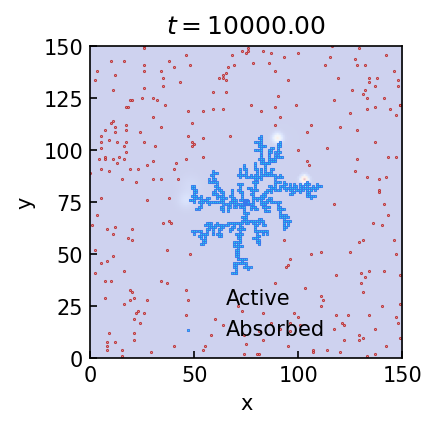

(<Figure size 450x450 with 1 Axes>,
 <Axes: title={'center': '$t=10000.00$'}, xlabel='x', ylabel='y'>,
 Text(0.5, 1.0, '$t=10000.00$'))

In [3]:
particle.plot(step = 10000, show_temp=True)

Allocating states: 100%|██████████| 5001/5001 [00:00<00:00, 27053.05it/s]


Old property n_particle=2000, dimension=2, n_step=5001
------------------------------------------------------------------
Updated property n_particle=2020, dimension=2, n_step=5001


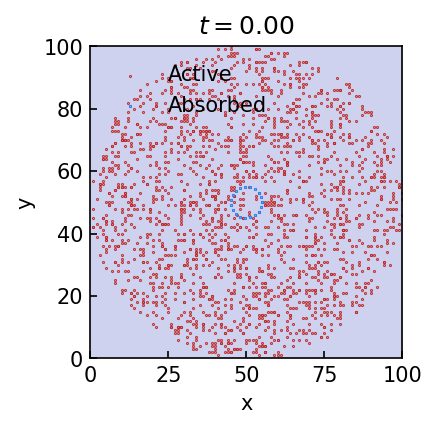

Updating Simulation: 100%|██████████| 5001/5001 [00:07<00:00, 648.97it/s]


In [15]:
particle = Particle(
    nums=2000, tmax=5000,
    boundary=[[0, 100], [0, 100]],
    init_shape="circle",
    init_center=(50, 50),
    init_radius=50,
    T_ambient=-15.0,
    latent_heat=10.0,
)

thetas = np.linspace(0, 2 * np.pi, 20)
x_active = 50 + 5 * np.cos(thetas)
y_active = 50 + 5 * np.sin(thetas)
particle.add_active_particles(added_position=np.array([x_active, y_active]), added_time=0)
particle.plot(step = 0, show_temp=True)
particle.update(fix_inactive=True)

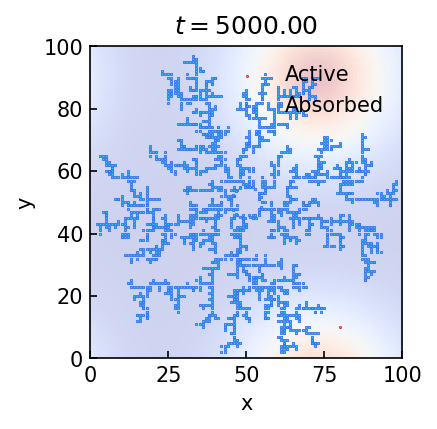

(<Figure size 450x450 with 1 Axes>,
 <Axes: title={'center': '$t=5000.00$'}, xlabel='x', ylabel='y'>,
 Text(0.5, 1.0, '$t=5000.00$'))

In [16]:
particle.plot(step = 5000, show_temp=True)

In [17]:
particle.save_gif(filename="simulation_heat.gif", fps=20, figsize=(4, 4), dpi=80,
                particle_size=8, frame_step=5)

Total steps: 5001, rendering 1001 frames
Saving GIF to simulation_heat.gif...
GIF save completed!
